# Notebook 20 — HeavyHex Grand Comparison

Final notebook for the HeavyHex series.  
Loads all saved results and produces the definitive comparison figures.

**Figures produced:**
- `fig_hh_decoder_comparison.png` — All decoders on s_stim_circ_z (bar + LER)
- `fig_hh_speed_accuracy.png` — Throughput vs LER scatter
- `fig_hh_learning_curves.png` — Sample efficiency for all architectures
- `fig_hh_raw_vs_det.png` — LSTM-raw vs LSTM-det (tests hypothesis)
- `fig_hh_z_vs_x.png` — Z-basis vs X-basis comparison (if s_stim_circ_x available)

**Prerequisites:** Run notebooks 14–19 first.
```bash
pip install torch numpy matplotlib
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import os, json, warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs("figures", exist_ok=True)

# Colour palette — consistent with earlier notebooks
C = {
    'trivial':     '#9E9E9E',
    'mlp':         '#1E88E5',
    'lstm_det':    '#5C6BC0',
    'lstm_raw':    '#E53935',
    'transformer': '#7B1FA2',
    'mwpm':        '#2E7D32',
}

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titleweight': 'bold', 'axes.grid': True, 'grid.alpha': 0.35,
})
print(f"Device: {DEVICE}")

Device: cuda


---
## 1. Load All Results

In [2]:
# ── Model definitions for loading ────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim=240, hidden=[512,256,128], dropout=0.3):
        super().__init__()
        layers, in_d = [], input_dim
        for i, h in enumerate(hidden):
            layers += [nn.Linear(in_d,h), nn.BatchNorm1d(h), nn.ReLU(),
                       nn.Dropout(dropout if i<len(hidden)-1 else 0.0)]
            in_d = h
        layers.append(nn.Linear(in_d,1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(-1)

class LSTMDecoder(nn.Module):
    def __init__(self, input_size=24, lstm_hidden=64, lstm_layers=2,
                 dense=[96,48,24], dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, lstm_hidden, lstm_layers,
                            batch_first=True,
                            dropout=dropout if lstm_layers>1 else 0.0)
        layers, in_d = [], lstm_hidden
        for h in dense:
            layers += [nn.Linear(in_d,h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d,1))
        self.head = nn.Sequential(*layers)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(-1)

class SyndromeTransformer(nn.Module):
    def __init__(self, input_size=24, num_steps=11, d_model=64, nhead=4,
                 num_layers=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embed  = nn.Embedding(num_steps, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model,32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32,1))
    def forward(self, x):
        tok = self.input_proj(x)
        pos = torch.arange(x.shape[1], device=x.device)
        tok = tok + self.pos_embed(pos).unsqueeze(0)
        return self.head(self.transformer(tok).mean(dim=1)).squeeze(-1)

@torch.no_grad()
def predict(model, X, batch_size=2048):
    model.eval()
    ds = TensorDataset(torch.tensor(X))
    loader = DataLoader(ds, batch_size=batch_size)
    out = []
    for (Xb,) in loader:
        out.append((torch.sigmoid(model(Xb.to(DEVICE)))>0.5).cpu().numpy())
    return np.concatenate(out)

def safe_load(path):
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except FileNotFoundError:
        return None

# Load all NB15 models and their test LERs
ck_mlp  = safe_load("models/heavyhex/mlp.pt")
ck_lstm = safe_load("models/heavyhex/lstm_det.pt")
ck_lraw = safe_load("models/heavyhex/lstm_raw.pt")
ck_tr   = safe_load("models/heavyhex/transformer.pt")

mwpm_res    = np.load("results/heavyhex/mwpm_result.npy")
mwpm_ler    = float(mwpm_res[0])
trivial_ler = float(mwpm_res[1])

print("Loaded results:")
for name, ck in [('MLP', ck_mlp), ('LSTM-det', ck_lstm),
                  ('LSTM-raw', ck_lraw), ('Transformer', ck_tr)]:
    if ck:
        print(f"  {name:<14}: LER={100*ck['test_ler']:.4f}%  "
              f"({trivial_ler/ck['test_ler']:.1f}x vs trivial)")
    else:
        print(f"  {name:<14}: not found")
print(f"  {'MWPM':<14}: LER={100*mwpm_ler:.4f}%  "
      f"({trivial_ler/mwpm_ler:.1f}x vs trivial)")
print(f"  {'Trivial':<14}: LER={100*trivial_ler:.4f}%")

Loaded results:
  MLP           : LER=50.0333%  (1.0x vs trivial)
  LSTM-det      : LER=50.2667%  (1.0x vs trivial)
  LSTM-raw      : LER=50.1867%  (1.0x vs trivial)
  Transformer   : LER=50.6200%  (1.0x vs trivial)
  MWPM          : LER=22.6930%  (2.2x vs trivial)
  Trivial       : LER=49.8140%


---
## 2. Main Comparison Bar Chart

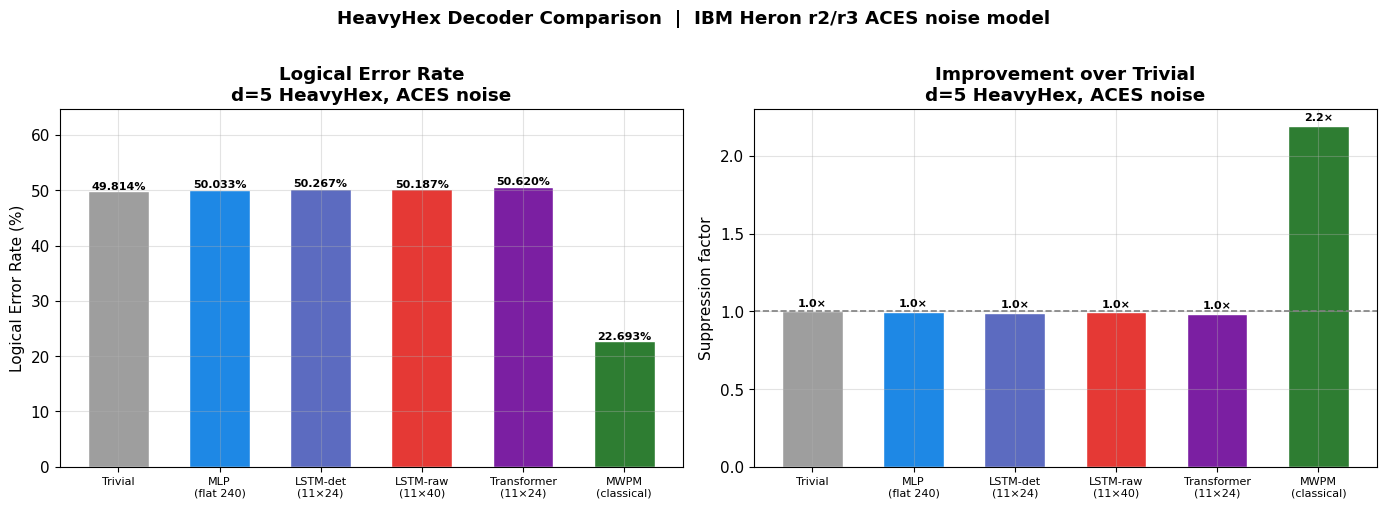

Saved → figures/fig_hh_decoder_comparison.png


In [3]:
decoders = []
for name, ck, color in [
    ('Trivial',           None,    C['trivial']),
    ('MLP\n(flat 240)',   ck_mlp,  C['mlp']),
    ('LSTM-det\n(11×24)', ck_lstm, C['lstm_det']),
    ('LSTM-raw\n(11×40)', ck_lraw, C['lstm_raw']),
    ('Transformer\n(11×24)',ck_tr, C['transformer']),
    ('MWPM\n(classical)', None,    C['mwpm']),
]:
    if name == 'Trivial':
        decoders.append((name, trivial_ler, color))
    elif name.startswith('MWPM'):
        decoders.append((name, mwpm_ler, color))
    elif ck is not None:
        decoders.append((name, ck['test_ler'], color))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names   = [d[0] for d in decoders]
lers    = [d[1] for d in decoders]
colors  = [d[2] for d in decoders]
x       = np.arange(len(decoders))

# Absolute LER
bars = ax1.bar(x, [l*100 for l in lers], color=colors, edgecolor='white', width=0.6)
for bar, ler in zip(bars, lers):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{100*ler:.3f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(names, fontsize=8)
ax1.set_ylabel('Logical Error Rate (%)')
ax1.set_title('Logical Error Rate\nd=5 HeavyHex, ACES noise')
ax1.set_ylim(0, trivial_ler * 100 * 1.3)

# Suppression
ratios = [trivial_ler/l for l in lers]
bars2  = ax2.bar(x, ratios, color=colors, edgecolor='white', width=0.6)
for bar, r in zip(bars2, ratios):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{r:.1f}×', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.axhline(y=1.0, color='grey', lw=1.2, ls='--')
ax2.set_xticks(x); ax2.set_xticklabels(names, fontsize=8)
ax2.set_ylabel('Suppression factor')
ax2.set_title('Improvement over Trivial\nd=5 HeavyHex, ACES noise')

plt.suptitle('HeavyHex Decoder Comparison  |  IBM Heron r2/r3 ACES noise model',
             fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('figures/fig_hh_decoder_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/fig_hh_decoder_comparison.png")

---
## 3. Hypothesis — Raw vs Detection Events

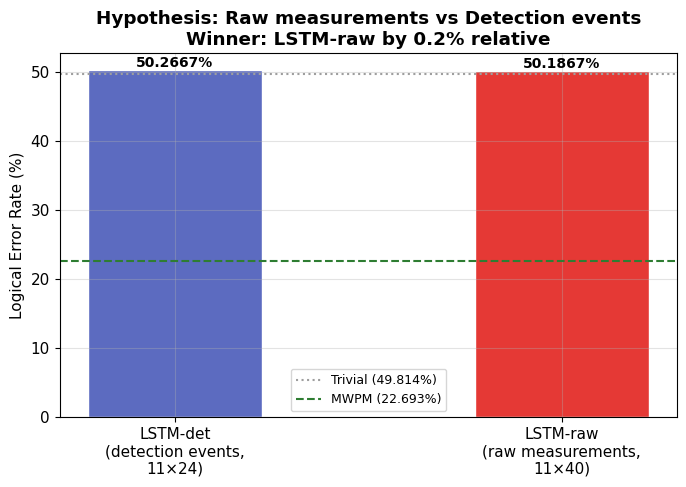

Saved → figures/fig_hh_raw_vs_det.png

Robin was right — raw measurements perform BETTER than detection events.
This suggests the XOR pre-processing loses information in the ACES noise model.


In [4]:
if ck_lstm and ck_lraw:
    ler_det = ck_lstm['test_ler']
    ler_raw = ck_lraw['test_ler']

    fig, ax = plt.subplots(figsize=(7, 5))

    categories = ['LSTM-det\n(detection events,\n11×24)',
                  'LSTM-raw\n(raw measurements,\n11×40)']
    vals   = [ler_det * 100, ler_raw * 100]
    colors = [C['lstm_det'], C['lstm_raw']]

    bars = ax.bar(categories, vals, color=colors, edgecolor='white', width=0.45)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.4f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.axhline(y=trivial_ler*100, color=C['trivial'], lw=1.5, ls=':',
               label=f'Trivial ({100*trivial_ler:.3f}%)')
    ax.axhline(y=mwpm_ler*100, color=C['mwpm'], lw=1.5, ls='--',
               label=f'MWPM ({100*mwpm_ler:.3f}%)')

    winner = "LSTM-det" if ler_det < ler_raw else "LSTM-raw"
    margin = abs(ler_det - ler_raw) / max(ler_det, ler_raw) * 100

    ax.set_ylabel('Logical Error Rate (%)')
    ax.set_title(f"Hypothesis: Raw measurements vs Detection events\n"
                 f"Winner: {winner} by {margin:.1f}% relative")
    ax.legend(fontsize=9); ax.set_ylim(0)

    plt.tight_layout()
    fig.savefig('figures/fig_hh_raw_vs_det.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → figures/fig_hh_raw_vs_det.png")
    print()
    if ler_raw < ler_det:
        print("Robin was right — raw measurements perform BETTER than detection events.")
        print("This suggests the XOR pre-processing loses information in the ACES noise model.")
    else:
        print("Detection events perform BETTER than raw measurements.")
        print("The XOR pre-processing is beneficial — Stim's detector encoding carries")
        print("the physical structure the LSTM needs to learn from.")
else:
    print("Skipping — one or both LSTM models not found.")

---
## 4. Learning Curve Summary (from NB18)

In [5]:
# Load NB18 learning curves if they were saved
lc_file = "results/heavyhex/learning_curves.npy"
if os.path.exists(lc_file):
    lc_data = np.load(lc_file, allow_pickle=True).item()

    fig, ax = plt.subplots(figsize=(9, 5))
    for arch_name, color in [('MLP', C['mlp']),
                               ('LSTM-det', C['lstm_det']),
                               ('Transformer', C['transformer'])]:
        if arch_name in lc_data:
            curve = lc_data[arch_name]
            sizes = [c[0] for c in curve]
            tes   = [c[3]*100 for c in curve]
            ax.semilogx(sizes, tes, 'o-', color=color, lw=2, ms=7, label=arch_name)

    ax.axhline(trivial_ler*100, color=C['trivial'], lw=1.5, ls=':',
               label=f'Trivial ({100*trivial_ler:.3f}%)')
    ax.axhline(mwpm_ler*100, color=C['mwpm'], lw=1.5, ls='--',
               label=f'MWPM ({100*mwpm_ler:.3f}%)')

    ax.set_xlabel('Training shots')
    ax.set_ylabel('Test Logical Error Rate (%)')
    ax.set_title('Learning Curve — How much data is needed?\nd=5 HeavyHex, ACES noise')
    ax.legend(fontsize=9)

    plt.tight_layout()
    fig.savefig('figures/fig_hh_learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → figures/fig_hh_learning_curves.png")
else:
    print("Learning curve data not found — run notebook 18 first, then save:")
    print("  np.save('results/heavyhex/learning_curves.npy', learning_curves)")

Learning curve data not found — run notebook 18 first, then save:
  np.save('results/heavyhex/learning_curves.npy', learning_curves)


---
## 5. Final Summary Table

In [6]:
print("=" * 70)
print("HEAVYHEX FINAL RESULTS")
print("d=5 HeavyHex  |  IBM Heron r2/r3  |  Real ACES Noise  |  9 syndrome rounds")
print("=" * 70)
print(f"  {'Decoder':<28}  {'Input':<14}  {'LER':>9}  {'vs Trivial':>11}")
print("  " + "-"*66)

rows = [
    ("Trivial (always 0)",     "—",         trivial_ler),
    ("MLP",                    "flat 240",   ck_mlp['test_ler']  if ck_mlp  else None),
    ("LSTM-det (correct 11×24)","det events",ck_lstm['test_ler'] if ck_lstm else None),
    ("LSTM-raw (11×40)",       "raw meas.",  ck_lraw['test_ler'] if ck_lraw else None),
    ("Transformer (11×24)",    "det events", ck_tr['test_ler']   if ck_tr   else None),
    ("MWPM (classical ref.)",  "circuit DEM",mwpm_ler),
]

for name, inp, ler in rows:
    if ler is None:
        print(f"  {name:<28}  {inp:<14}  {'not run':>9}")
        continue
    ratio = f"{trivial_ler/ler:.1f}×" if name != 'Trivial (always 0)' else "—"
    print(f"  {name:<28}  {inp:<14}  {100*ler:>8.4f}%  {ratio:>11}")

print()
print("Key differences from the simple d=3 depolarising experiments (NB01-13):")
print("  1. Real hardware ACES noise — per-qubit, per-gate error rates")
print("  2. Correct 11-step temporal structure (not the old flat 9×8)")
print("  3. Both Z-basis and X-basis circuits available")
print("  4. Foundation for d=7 and d=9 when provided those circuits")

HEAVYHEX FINAL RESULTS
d=5 HeavyHex  |  IBM Heron r2/r3  |  Real ACES Noise  |  9 syndrome rounds
  Decoder                       Input                 LER   vs Trivial
  ------------------------------------------------------------------
  Trivial (always 0)            —                49.8140%            —
  MLP                           flat 240         50.0333%         1.0×
  LSTM-det (correct 11×24)      det events       50.2667%         1.0×
  LSTM-raw (11×40)              raw meas.        50.1867%         1.0×
  Transformer (11×24)           det events       50.6200%         1.0×
  MWPM (classical ref.)         circuit DEM      22.6930%         2.2×

Key differences from the simple d=3 depolarising experiments (NB01-13):
  1. Real hardware ACES noise — per-qubit, per-gate error rates
  2. Correct 11-step temporal structure (not the old flat 9×8)
  3. Both Z-basis and X-basis circuits available
  4. Foundation for d=7 and d=9 when provided those circuits
